<a href="https://colab.research.google.com/github/arman-hossain45/ML_Pipe_Line/blob/main/ml_neural_pipe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***# Air population prediction***

In [206]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
from torch import nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder

import warnings
warnings.filterwarnings('ignore')


In [207]:
df=pd.read_csv('air.csv')
df.head(5)

,pm25,pm10,no2,temperature,wind_speed,area_type,air_quality_index,pollution_level
0,38.168799,76.762174,15.294843,32.075944,2.378728,urban,58.506476,Low
1,74.228186,136.819101,17.739587,22.581570,3.010191,rural,26.597234,High
2,81.832202,56.656485,25.386812,27.716089,NaN,suburban,24.728427,High
3,59.383912,129.380144,NaN,30.227755,2.435249,suburban,27.232939,High
4,33.581227,NaN,NaN,25.377335,4.084020,urban,72.412090,Low


In [208]:
df.isnull().sum()

,0
pm25,56
pm10,69
no2,83
temperature,93
wind_speed,89
area_type,75
air_quality_index,0
pollution_level,0


In [209]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pm25,944.0,55.670370,19.802257,5.000000,42.602042,55.638736,68.716883,120.910050
pm10,931.0,89.354734,30.567718,10.000000,68.760394,89.302096,109.487329,188.215958
no2,917.0,39.556342,14.313400,5.000000,29.615259,39.749819,49.246314,85.264473
temperature,907.0,27.781754,6.080381,7.688113,23.815204,27.711058,31.589643,45.000000
wind_speed,911.0,2.536100,1.127630,0.200000,1.717308,2.523631,3.302811,6.403153
air_quality_index,1000.0,48.721559,16.692888,0.000000,37.066982,49.249500,60.250007,99.116885


In [210]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pm25               944 non-null    float64
 1   pm10               931 non-null    float64
 2   no2                917 non-null    float64
 3   temperature        907 non-null    float64
 4   wind_speed         911 non-null    float64
 5   area_type          925 non-null    object 
 6   air_quality_index  1000 non-null   float64
 7   pollution_level    1000 non-null   object 
dtypes: float64(6), object(2)
memory usage: 62.6+ KB


In [211]:
num_feature=df.select_dtypes(include=['int64','float64'])
cat_feature=df.select_dtypes(include=['object'])

In [212]:
num_feature

,pm25,pm10,no2,temperature,wind_speed,air_quality_index
0,38.168799,76.762174,15.294843,32.075944,2.378728,58.506476
1,74.228186,136.819101,17.739587,22.581570,3.010191,26.597234
2,81.832202,56.656485,25.386812,27.716089,NaN,24.728427
3,59.383912,129.380144,NaN,30.227755,2.435249,27.232939
4,33.581227,NaN,NaN,25.377335,4.084020,72.412090
...,...,...,...,...,...,...
995,50.001404,94.099119,53.195288,30.417425,3.403971,45.722274
996,53.252702,71.626187,67.435038,30.915947,3.306654,32.104892
997,75.727993,93.408112,55.020673,23.374284,2.694312,35.276779
998,33.694749,113.712335,65.371697,35.154931,2.603847,37.594205


In [213]:
cat_feature

,area_type,pollution_level
0,urban,Low
1,rural,High
2,suburban,High
3,suburban,High
4,urban,Low
...,...,...
995,NaN,High
996,NaN,High
997,suburban,High
998,suburban,High


In [214]:
import seaborn as sns

<Axes: >

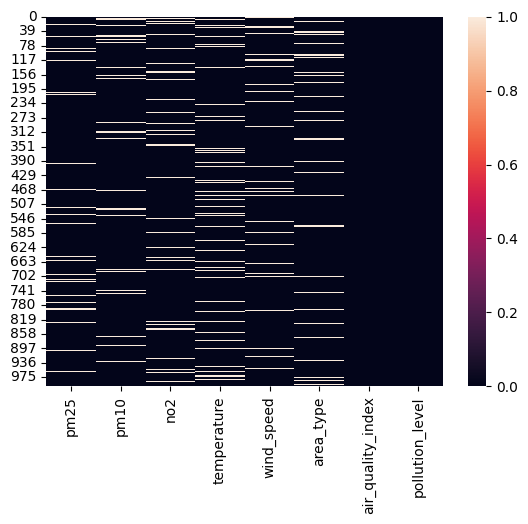

In [215]:
sns.heatmap(df.isnull())


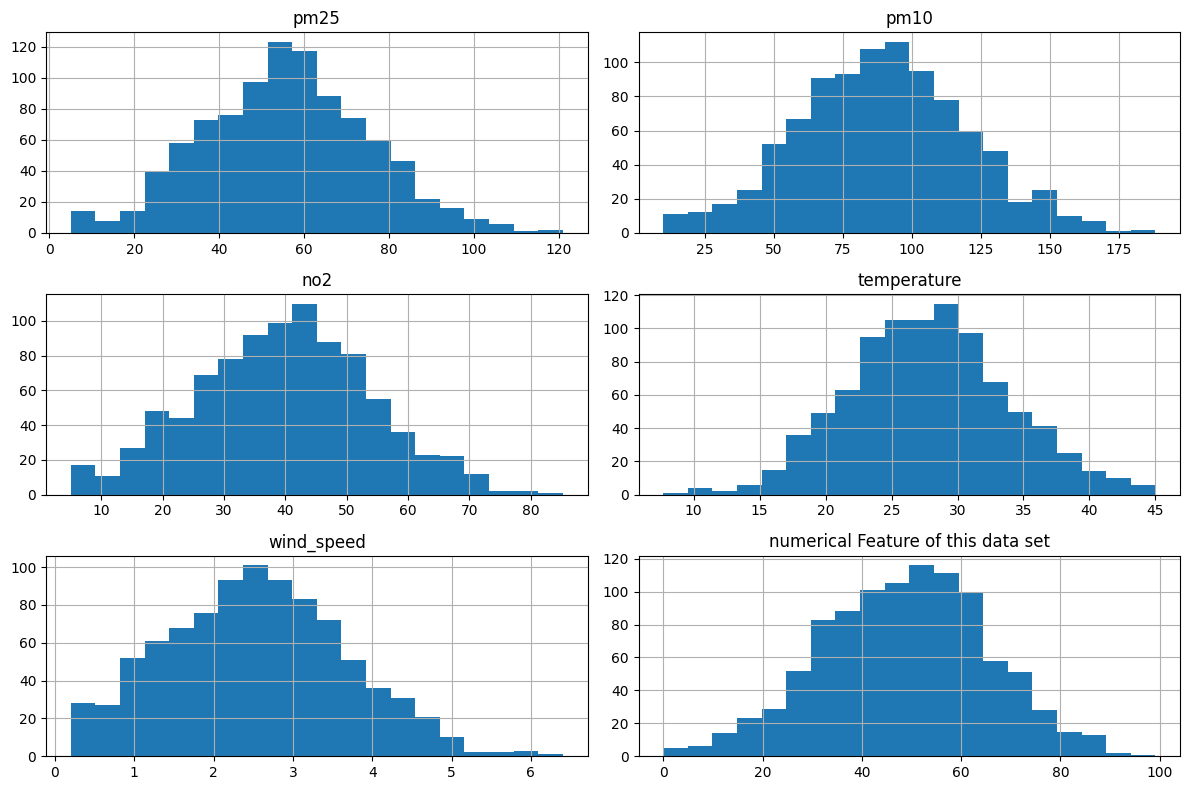

In [216]:
df[num_feature.columns].hist(bins=20,figsize=(12,8))
plt.tight_layout()
plt.title("numerical Feature of this data set")
plt.show()

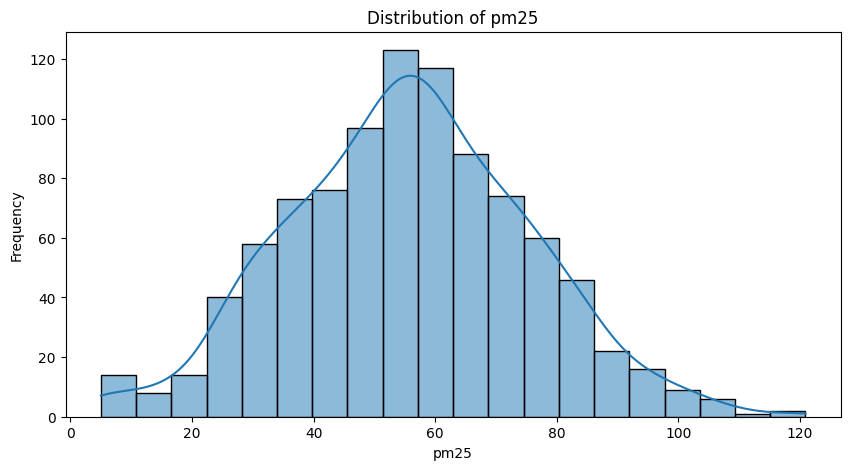

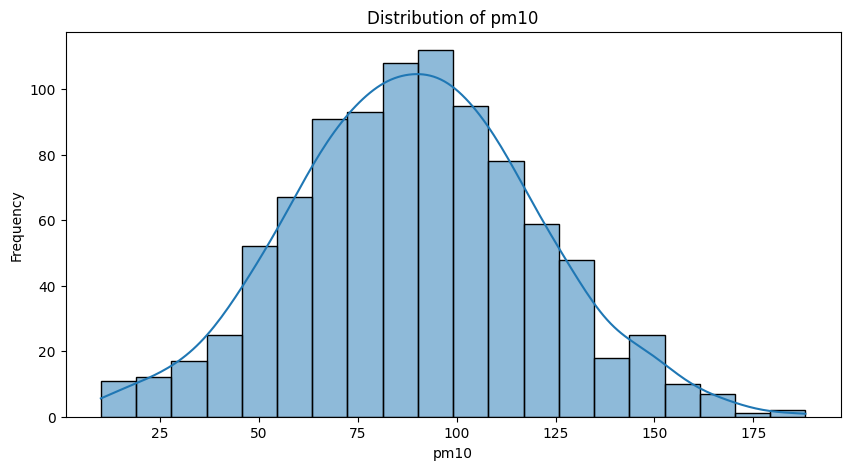

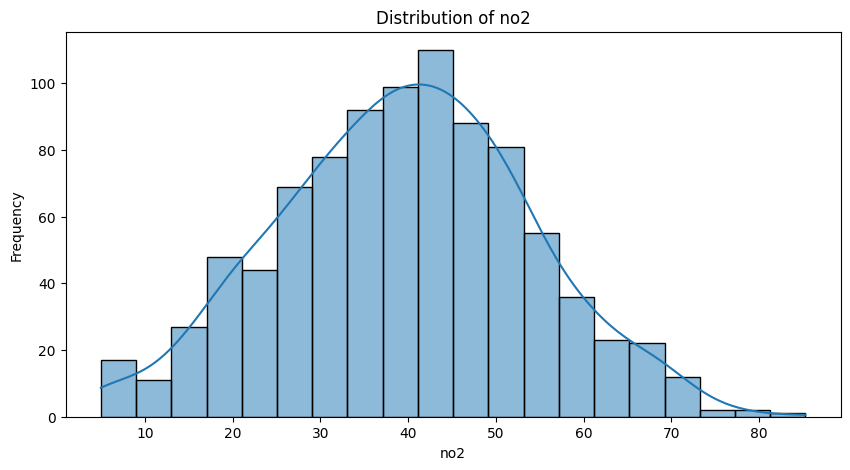

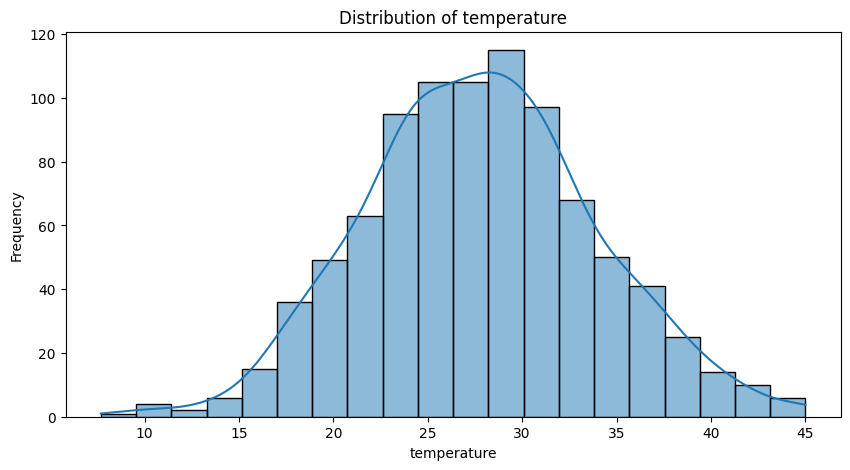

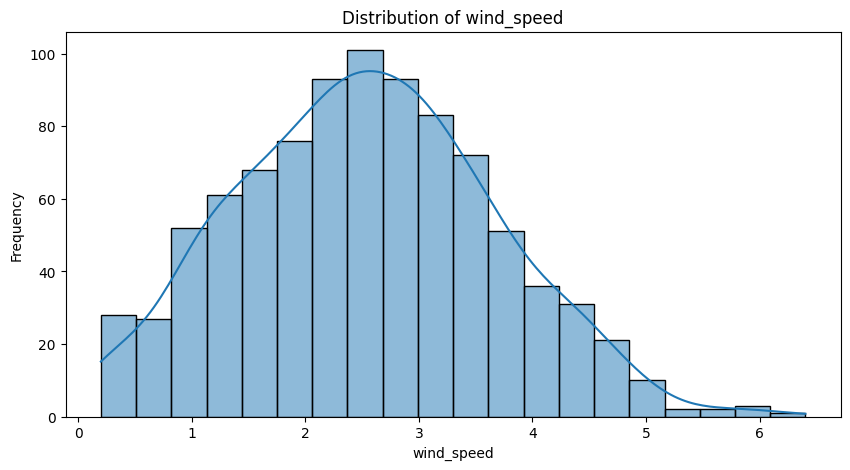

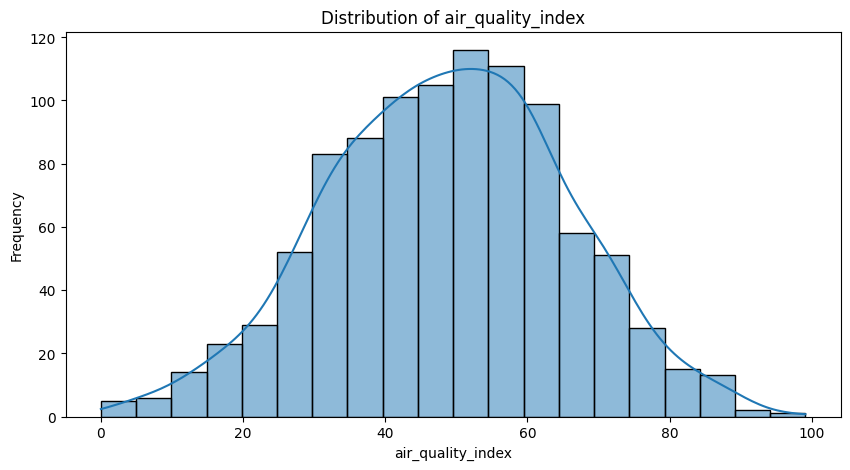

In [217]:
for col in num_feature.columns:
   plt.figure(figsize=(10,5))
   sns.histplot(df[col],kde=True,bins=20)
   plt.title(f"Distribution of {col}")
   plt.xlabel(col)
   plt.ylabel("Frequency")
   plt.show()

In [218]:
df.columns

Index(['pm25', 'pm10', 'no2', 'temperature', 'wind_speed', 'area_type',
       'air_quality_index', 'pollution_level'],
      dtype='object')

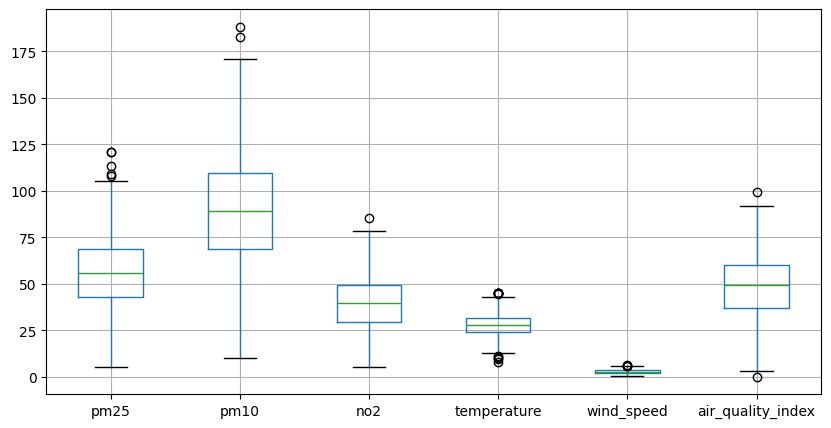

In [219]:
plt.figure(figsize=(10,5))
df[num_feature.columns].boxplot()
plt.show()


In [220]:
col='temperature'
q1=df[col].quantile(0.25)
q3=df[col].quantile(0.75)
IQR=q3-q1
lower=q1-1.5*IQR
upper=q3+1.5*IQR

outliar = df[(df[col]<lower)|(df[col]>upper)]
print(f"Number of detected outliar is {col}",len(outliar))




Number of detected outliar is temperature 11


In [221]:
df=df.copy()
df[col]=df[col].clip(lower,upper)

In [222]:
col='pm25'
q1=df[col].quantile(0.25)
q3=df[col].quantile(0.75)
IQR=q3-q1
lower=q1-1.5*IQR
upper=q3+1.5*IQR

outliar = df[(df[col]<lower)|(df[col]>upper)]
print(f"Number of detected outliar is {col}",len(outliar))




Number of detected outliar is pm25 5


In [223]:
df=df.copy()
df[col]=df[col].clip(lower,upper)

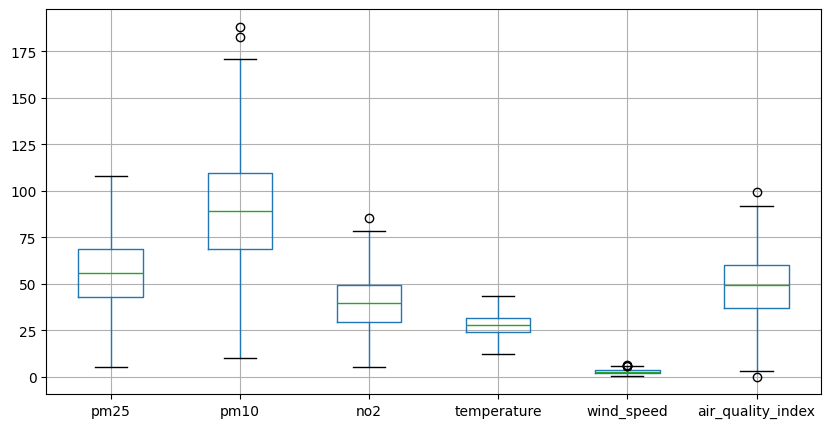

In [224]:
plt.figure(figsize=(10,5))
df[num_feature.columns].boxplot()
plt.show()


In [225]:
df.shape

(1000, 8)

In [226]:
df.head(5)

,pm25,pm10,no2,temperature,wind_speed,area_type,air_quality_index,pollution_level
0,38.168799,76.762174,15.294843,32.075944,2.378728,urban,58.506476,Low
1,74.228186,136.819101,17.739587,22.581570,3.010191,rural,26.597234,High
2,81.832202,56.656485,25.386812,27.716089,NaN,suburban,24.728427,High
3,59.383912,129.380144,NaN,30.227755,2.435249,suburban,27.232939,High
4,33.581227,NaN,NaN,25.377335,4.084020,urban,72.412090,Low


In [227]:
df.isnull().sum()

,0
pm25,56
pm10,69
no2,83
temperature,93
wind_speed,89
area_type,75
air_quality_index,0
pollution_level,0


In [228]:
#Missing value handeling
pm25=df['pm25'].mean()
df['pm25']=df['pm25'].fillna(pm25)
pm10=df['pm10'].mean()
df['pm10']=df['pm10'].fillna(pm10)
no2=df['no2'].mean()
df['no2']=df['no2'].fillna(no2)
tem=df['temperature'].mean()
df['temperature']=df['temperature'].fillna(tem)
wind=df['wind_speed'].mean()
df['wind_speed']=df['wind_speed'].fillna(wind)
area=df['area_type'].mode()[0]
df['area_type']=df['area_type'].fillna(area)

df.isnull().sum()

,0
pm25,0
pm10,0
no2,0
temperature,0
wind_speed,0
area_type,0
air_quality_index,0
pollution_level,0


In [229]:
df.head(10)

,pm25,pm10,no2,temperature,wind_speed,area_type,air_quality_index,pollution_level
0,38.168799,76.762174,15.294843,32.075944,2.378728,urban,58.506476,Low
1,74.228186,136.819101,17.739587,22.581570,3.010191,rural,26.597234,High
2,81.832202,56.656485,25.386812,27.716089,2.536100,suburban,24.728427,High
3,59.383912,129.380144,39.556342,30.227755,2.435249,suburban,27.232939,High
4,33.581227,89.354734,39.556342,25.377335,4.084020,urban,72.412090,Low
5,95.103549,112.200345,54.858242,17.892622,3.084281,suburban,26.139237,High
6,44.980320,94.134468,35.619717,27.138495,3.307176,rural,62.588044,Low
7,32.553036,89.354734,43.915670,27.783911,3.057392,urban,48.982326,High
8,68.534092,75.903402,24.025623,26.259419,2.780351,suburban,61.527788,Low
9,22.351610,82.498179,24.685602,28.950310,4.155836,urban,73.235311,Low


In [230]:
le=LabelEncoder()
df['pollution_level']=le.fit_transform(df['pollution_level'])

In [231]:
df.head(5)

,pm25,pm10,no2,temperature,wind_speed,area_type,air_quality_index,pollution_level
0,38.168799,76.762174,15.294843,32.075944,2.378728,urban,58.506476,1
1,74.228186,136.819101,17.739587,22.581570,3.010191,rural,26.597234,0
2,81.832202,56.656485,25.386812,27.716089,2.536100,suburban,24.728427,0
3,59.383912,129.380144,39.556342,30.227755,2.435249,suburban,27.232939,0
4,33.581227,89.354734,39.556342,25.377335,4.084020,urban,72.412090,1


In [232]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# encoder create
encoder = OneHotEncoder(sparse_output=False)

# fit & transform only area_type column
encoded = encoder.fit_transform(df[["area_type"]])

# convert to dataframe with proper column names
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["area_type"])
)


df = pd.concat([df.drop("area_type", axis=1), encoded_df], axis=1)



In [233]:
df.head(4)

,pm25,pm10,no2,temperature,wind_speed,air_quality_index,pollution_level,area_type_rural,area_type_suburban,area_type_urban
0,38.168799,76.762174,15.294843,32.075944,2.378728,58.506476,1,0.0,0.0,1.0
1,74.228186,136.819101,17.739587,22.581570,3.010191,26.597234,0,1.0,0.0,0.0
2,81.832202,56.656485,25.386812,27.716089,2.536100,24.728427,0,0.0,1.0,0.0
3,59.383912,129.380144,39.556342,30.227755,2.435249,27.232939,0,0.0,1.0,0.0


In [234]:
x=df.drop('pollution_level',axis=1)
y=df['pollution_level']

In [235]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [236]:
scaler = StandardScaler()

# Train data → fit + transform
x_train_encoded = scaler.fit_transform(x_train)

# Test data → only transform
x_test_encoded = scaler.transform(x_test)

In [237]:
x_train_encoded.shape

(800, 9)

In [238]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [239]:
rf=RandomForestClassifier(n_estimators=200,min_samples_leaf=5,min_samples_split=5,random_state=42)

rf.fit(x_train_encoded,y_train)
y_pred=rf.predict(x_test_encoded)
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

1.0


In [240]:
y_pred_train=rf.predict(x_train_encoded)
accuracy_train=accuracy_score(y_train,y_pred_train)
print(accuracy_train)

1.0


# Now we apply this in a pytorch ann code apply step by step in details

In [241]:
y_train

,pollution_level
29,1
535,1
695,1
557,1
836,0
...,...
106,1
270,0
860,1
435,0


# Numpy array to tensor convert

In [242]:
x_train_tensor=torch.from_numpy(x_train_encoded)
x_test_tensor=torch.from_numpy(x_test_encoded)

x_train_tensor= torch.tensor(x_train_encoded,dtype=torch.float32)
x_test_tensor= torch.tensor(x_test_encoded,dtype=torch.float32)


y_train_tensor= torch.tensor(y_train.values,dtype=torch.float32)
y_test_tensor= torch.tensor(y_test.values,dtype=torch.float32)


In [243]:
x_train_tensor.shape

torch.Size([800, 9])

# Define  the NN model un details

In [244]:
class MyNN(nn.Module):
  def __init__(self,num_feature):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_feature,1200),
        nn.ReLU(),
        nn.Linear(1200,900),
        nn.ReLU(),
        nn.Linear(900,300),
        nn.ReLU(),
        nn.Linear(300,1),
        nn.Sigmoid()
    )


  def forward(self,feature):
    return self.model(feature)



model = MyNN(x_train_tensor.shape[1])

In [245]:
! pip install torchinfo

In [246]:
from torchinfo import summary
summary(model)

Layer (type:depth-idx)                   Param #
MyNN                                     --
├─Sequential: 1-1                        --
│    └─Linear: 2-1                       12,000
│    └─ReLU: 2-2                         --
│    └─Linear: 2-3                       1,080,900
│    └─ReLU: 2-4                         --
│    └─Linear: 2-5                       270,300
│    └─ReLU: 2-6                         --
│    └─Linear: 2-7                       301
│    └─Sigmoid: 2-8                      --
Total params: 1,363,501
Trainable params: 1,363,501
Non-trainable params: 0

# Define the parameter

In [247]:
# import parameters
learning_rate =0.001
epochs=200

#define the loss function
loss_fun = nn.BCELoss()

#define the optimizer

optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)



# define the loop

In [248]:
for epoch in range(epochs):
  #forwRD pass
  y_pred = model(x_train_tensor)
  #Loss calculate
  loss=loss_fun(y_pred,y_train_tensor.unsqueeze(1))
  # zero grad
  optimizer.zero_grad()
  #back ward pass
  loss.backward()
  #parameters upgrade
  optimizer.step()

  # print epoch for 10 step
  if(epoch+1)%20==0:
    print(f"Epoch :{epoch},loss :{loss.item()}")

Epoch :19,loss :0.6899195909500122
Epoch :39,loss :0.687643826007843
Epoch :59,loss :0.6853746175765991
Epoch :79,loss :0.6831105947494507
Epoch :99,loss :0.6808483600616455
Epoch :119,loss :0.6785838603973389
Epoch :139,loss :0.6763114929199219
Epoch :159,loss :0.6740244030952454
Epoch :179,loss :0.6717230081558228
Epoch :199,loss :0.6693997383117676


In [252]:
# calculate the accuracy

with torch.no_grad():
  y_pred = model(x_test_tensor)
  y_pred = (y_pred>0.5).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f"Accuracy :{accuracy}")

Accuracy :0.485150009393692
